# Practice Performing Exploraty Data Analysis (EDA) Using Pandas
# CS240 : Principle of Data Science

## 1. Import Pandas library

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## 2. Read dataset (csv file) into a Pandas dataframe.

#### <u>หมายเหตุ</u> ชุดข้อมูล GrinnellHouses.csv เป็นข้อมูลเกี่ยวกับการซื้อขายบ้านในเมือง Grinnell รัฐ Iowa ซึ่งประกอบไปด้วยคอลัมน์หลัก ๆ เช่น Bedrooms (จำนวนห้องนอน), Baths (จำนวนห้องน้ำ), YearBuilt (ปีที่สร้าง), YearSold (ปีที่ขาย), MonthSold (เดือนที่ขาย), และข้อมูลราคาอย่าง SalePrice หรือ ListPrice

In [9]:
url = "https://vincentarelbundock.github.io/Rdatasets/csv/Stat2Data/GrinnellHouses.csv"
file_path: Path = Path('./GrinnellHouse.csv')
df = pd.read_csv(file_path if file_path.is_file else url)
df

,rownames,Date,Address,Bedrooms,Baths,SquareFeet,LotSize,YearBuilt,YearSold,MonthSold,DaySold,CostPerSqFt,OrigPrice,ListPrice,SalePrice,SPLPPct
0,1,16695,1510 First Ave #112,2,1.0,1120.0,NaN,1993,2005,9,16,6.25,17000,10500,7000,66.67
1,2,16880,1020 Center St,3,1.0,1224.0,0.172176,1900,2006,3,20,22.06,35000,35000,27000,77.14
2,3,16875,918 Chatterton St,4,1.0,1540.0,NaN,1970,2006,3,15,18.18,54000,47000,28000,59.57
3,4,16833,1023 & 1025 Spring St.,3,1.0,1154.0,NaN,1900,2006,2,1,26.00,65000,49000,30000,61.22
4,5,16667,503 2nd Ave,3,1.0,1277.0,0.206612,1900,2005,8,19,24.08,35000,35000,30750,87.86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
924,925,20080,569 Hwy 6,4,3.0,1920.0,4.000000,2006,2014,12,23,169.27,420000,355000,325000,91.55
925,926,19963,2000 Country Club Dr,4,3.0,2958.0,0.370000,1968,2014,8,28,121.70,369000,369000,360000,97.56
926,927,20048,311 11th Ave,4,3.0,3359.0,2.000000,1993,2014,11,21,107.92,449000,385000,362500,94.16
927,928,20153,384 450th Ave,3,2.5,1565.0,11.660000,1987,2015,3,6,258.79,425000,425000,405000,95.29


## 3. See brief information about ``features`` / ``attributes`` / ``columms`` of the dataset.

#### <u>Note</u>! Student should notice the information about each data column we could obtain from ``pandas.DataFrame.info()``

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 929 entries, 0 to 928
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   rownames     929 non-null    int64  
 1   Date         929 non-null    int64  
 2   Address      929 non-null    str    
 3   Bedrooms     929 non-null    int64  
 4   Baths        929 non-null    float64
 5   SquareFeet   911 non-null    float64
 6   LotSize      741 non-null    float64
 7   YearBuilt    929 non-null    int64  
 8   YearSold     929 non-null    int64  
 9   MonthSold    929 non-null    int64  
 10  DaySold      929 non-null    int64  
 11  CostPerSqFt  929 non-null    float64
 12  OrigPrice    929 non-null    int64  
 13  ListPrice    929 non-null    int64  
 14  SalePrice    929 non-null    int64  
 15  SPLPPct      929 non-null    float64
dtypes: float64(5), int64(10), str(1)
memory usage: 116.3 KB


Data show LostSize 741 that mean there have outliers around 700+ data

## 4. Descriptive Statistics

#### <u>Note</u>! Available for columns with numeric data only.

In [10]:
df.describe()

,rownames,Date,Bedrooms,Baths,SquareFeet,LotSize,YearBuilt,YearSold,MonthSold,DaySold,CostPerSqFt,OrigPrice,ListPrice,SalePrice,SPLPPct
count,929.000000,929.000000,929.000000,929.000000,911.000000,741.000000,929.000000,929.000000,929.000000,929.000000,929.000000,929.000000,929.000000,929.000000,929.000000
mean,465.000000,18223.215285,3.194833,1.779333,1583.215148,0.723463,1945.903122,2009.365985,6.831001,16.226050,83.291561,146047.083961,141399.138859,133203.720129,93.563994
std,268.323499,1139.171002,0.943293,0.743154,655.664966,2.725697,37.209902,3.124149,3.035790,9.396815,35.762241,85174.109372,82228.201763,77959.624697,6.953764
min,1.000000,16527.000000,0.000000,0.000000,640.000000,0.028926,1870.000000,2005.000000,1.000000,1.000000,0.000000,5990.000000,10500.000000,7000.000000,46.500000
25%,233.000000,17169.000000,3.000000,1.000000,1150.000000,0.233884,1900.000000,2007.000000,5.000000,8.000000,60.820000,89900.000000,88000.000000,83000.000000,91.320000
50%,465.000000,18046.000000,3.000000,1.750000,1440.000000,0.284091,1956.000000,2009.000000,7.000000,16.000000,82.880000,129900.000000,125000.000000,119340.000000,94.920000
75%,697.000000,19281.000000,4.000000,2.000000,1833.000000,0.370179,1973.000000,2012.000000,9.000000,25.000000,105.770000,179000.000000,172000.000000,162500.000000,97.560000
max,929.000000,20186.000000,8.000000,6.000000,6815.000000,55.000000,2013.000000,2015.000000,12.000000,31.000000,258.790000,695000.000000,695000.000000,606000.000000,111.020000


## 5. ตัวอย่างการใช้ groupby()

### 5.1. จัดกลุ่มตามจำนวนห้องนอน (Bedrooms) และคำนวณราคาขายเฉลี่ยของแต่ละกลุ่ม

<u>Note</u>! ราคาขายเฉลี่ย แยกตามจำนวนห้องนอน

<u>Note</u>! บ้านที่จำนวนห้องนอนต่างกัน จะขายได้ราคาแตกต่างกันอย่างไร?

Groupby(WhatFeature)[What to watch]

In [13]:
df.groupby('Bedrooms')['SalePrice']

In [14]:
df.groupby('Bedrooms')['SalePrice'].mean()

Bedrooms
0    155597.250000
1     69500.000000
2     82203.026846
3    124549.207343
4    159478.750000
5    216334.426230
6    233500.000000
7     81000.000000
8    205000.000000
Name: SalePrice, dtype: float64

In [15]:
df.groupby('Bedrooms')['SalePrice'].mean().round(2)

Bedrooms
0    155597.25
1     69500.00
2     82203.03
3    124549.21
4    159478.75
5    216334.43
6    233500.00
7     81000.00
8    205000.00
Name: SalePrice, dtype: float64

### 5.2. ราคาขายเฉลี่ย แยกตามปีที่ขาย

<u>Note</u>! ราคาขายบ้านเฉลี่ยเปลี่ยนแปลงอย่างไรในแต่ละปี?

In [16]:
df.groupby("YearSold")["SalePrice"].mean().round(2)

YearSold
2005    118874.50
2006    132502.10
2007    127287.15
2008    137206.13
2009    104504.25
2010    123717.92
2011    141321.21
2012    142248.89
2013    143574.65
2014    146420.94
2015    137657.89
Name: SalePrice, dtype: float64

The Tend of YearSold with SalePrice is increased for each year

### 5.3. จำนวนบ้านที่ขายในแต่ละปี

In [17]:
df.groupby("YearSold").size()

YearSold
2005    100
2006    131
2007    111
2008    106
2009     53
2010     53
2011     66
2012     97
2013     94
2014     99
2015     19
dtype: int64

In [18]:
df.groupby("YearSold").size().reset_index(name="Count")

,YearSold,Count
0,2005,100
1,2006,131
2,2007,111
3,2008,106
4,2009,53
5,2010,53
6,2011,66
7,2012,97
8,2013,94
9,2014,99


The Tend show deceasing of bought house in each year increase.

### 🚀 **Challenge** : คำสั่งต่อไปนี้แสดงข้อมูลอะไร? ต่างจากคำสั่งด้านบนอย่างไร?

``df.groupby("YearSold")["SalePrice"].mean()``

แสดงความสัมพันธ์ของ YearSold กับ SalePrice โดยเอาค่าเฉลี่ยของแต่ละปี

In [20]:
df.groupby("YearSold")["SalePrice"].mean()

YearSold
2005    118874.500000
2006    132502.099237
2007    127287.153153
2008    137206.132075
2009    104504.245283
2010    123717.924528
2011    141321.212121
2012    142248.886598
2013    143574.648936
2014    146420.939394
2015    137657.894737
Name: SalePrice, dtype: float64

### **Your Answer.**

### 5.4. ใช้ ``agg()`` เพื่อสั่งให้คำนวณและแสดงค่าสถิติหลายๆ ค่า พร้อมกัน

In [19]:
df.groupby("Bedrooms")["SalePrice"].agg(
    ["count", "mean", "min", "max"]
)

,count,mean,min,max
Bedrooms,,,,
0,12,155597.250000,20000,381667
1,7,69500.000000,38000,121500
2,149,82203.026846,7000,200000
3,463,124549.207343,9300,425000
4,228,159478.750000,15000,452000
5,61,216334.426230,40000,606000
6,7,233500.000000,50000,400000
7,1,81000.000000,81000,81000
8,1,205000.000000,205000,205000


In [24]:
result = df.groupby("Bedrooms")["SalePrice"].agg(["count", "mean", "min", "max"])
result["mean"] = result["mean"].round(2)
result

,count,mean,min,max
Bedrooms,,,,
0,12,155597.25,20000,381667
1,7,69500.00,38000,121500
2,149,82203.03,7000,200000
3,463,124549.21,9300,425000
4,228,159478.75,15000,452000
5,61,216334.43,40000,606000
6,7,233500.00,50000,400000
7,1,81000.00,81000,81000
8,1,205000.00,205000,205000


## 6. ``pandas.crosstab()``

* ### Cross Tabulation
* ### ใช้สำหรับนับความถี่ของข้อมูลเมื่อแบ่งตามตัวแปรตั้งแต่ 2 ตัวขึ้นไป

### 6.1. ในแต่ละปี (YearSold) มีบ้านขายได้กี่หลัง แสดงผลแยกตามจำนวนห้องนอน (Bedrooms) ด้วย

In [25]:
pd.crosstab(df["YearSold"], df["Bedrooms"])

Bedrooms,0,1,2,3,4,5,6,7,8
YearSold,,,,,,,,,
2005,1,0,15,54,21,7,1,1,0
2006,1,0,18,64,39,8,0,0,1
2007,0,0,24,56,24,6,1,0,0
2008,1,2,17,59,17,8,2,0,0
2009,0,1,14,25,10,3,0,0,0
2010,0,0,10,27,14,2,0,0,0
2011,3,0,10,31,14,8,0,0,0
2012,3,1,11,47,28,6,1,0,0
2013,1,2,18,39,28,4,2,0,0


Tend of Sold House is nearly 2006 and most popular around 3 Bedroom.

In [26]:
pd.crosstab(df["YearSold"], df["Bedrooms"], margins=True)

Bedrooms,0,1,2,3,4,5,6,7,8,All
YearSold,,,,,,,,,,
2005,1,0,15,54,21,7,1,1,0,100
2006,1,0,18,64,39,8,0,0,1,131
2007,0,0,24,56,24,6,1,0,0,111
2008,1,2,17,59,17,8,2,0,0,106
2009,0,1,14,25,10,3,0,0,0,53
2010,0,0,10,27,14,2,0,0,0,53
2011,3,0,10,31,14,8,0,0,0,66
2012,3,1,11,47,28,6,1,0,0,97
2013,1,2,18,39,28,4,2,0,0,94


## 7. Let's Take a Look at ``df.iloc`` vs. ``df.loc``

### 7.1. ``iloc``

*   ### ย่อมาจาก Integer Location
*   ### ใช้เลือก แถว (rows) และคอลัมน์ (columns) ด้วยตำแหน่งตัวเลข (index position) เริ่มนับจาก 0

> ### ``df.iloc[row_index, column_index]``

In [31]:
# Select one element
df.iloc[0, 2]

'1510 First Ave #112 '

In [28]:
# Select 1 row (แถวแรกของ DataFrame)
df.iloc[0]

rownames                          1
Date                          16695
Address        1510 First Ave #112 
Bedrooms                          2
Baths                           1.0
SquareFeet                   1120.0
LotSize                         NaN
YearBuilt                      1993
YearSold                       2005
MonthSold                         9
DaySold                          16
CostPerSqFt                    6.25
OrigPrice                     17000
ListPrice                     10500
SalePrice                      7000
SPLPPct                       66.67
Name: 0, dtype: object

In [34]:
# Select multiple rows (row#0 - #4)
df.iloc[1:6:2]

,rownames,Date,Address,Bedrooms,Baths,SquareFeet,LotSize,YearBuilt,YearSold,MonthSold,DaySold,CostPerSqFt,OrigPrice,ListPrice,SalePrice,SPLPPct
1,2,16880,1020 Center St,3,1.0,1224.0,0.172176,1900,2006,3,20,22.06,35000,35000,27000,77.14
3,4,16833,1023 & 1025 Spring St.,3,1.0,1154.0,NaN,1900,2006,2,1,26.00,65000,49000,30000,61.22
5,6,16583,9090 Clay St,3,1.0,1079.0,0.199357,1900,2005,5,27,38.92,45900,45900,42000,91.50


In [33]:
# Select multiple columns and multiple rows
# (row #0 - #4 และ col #0 - #2)
df.iloc[0:5, 0:3]

,rownames,Date,Address
0,1,16695,1510 First Ave #112
1,2,16880,1020 Center St
2,3,16875,918 Chatterton St
3,4,16833,1023 & 1025 Spring St.
4,5,16667,503 2nd Ave


In [ ]:
# Select a single column
# row #2
df.iloc[:, 2]

In [35]:
# เลือกหลายคอลัมน์ที่ไม่ต่อเนื่องกัน
df.iloc[:, [1, 3, 5]]

,Date,Bedrooms,SquareFeet
0,16695,2,1120.0
1,16880,3,1224.0
2,16875,4,1540.0
3,16833,3,1154.0
4,16667,3,1277.0
...,...,...,...
924,20080,4,1920.0
925,19963,4,2958.0
926,20048,4,3359.0
927,20153,3,1565.0


In [ ]:
# ดูบ้าน 10 หลังแรก เฉพาะข้อมูลที่สนใจ
df.iloc[0:10, [2, 3, 4, 12, 13, 14]]

In [36]:
# ดูทุกคอลัมน์ของบ้าน 5 หลังสุดท้าย
df.iloc[-5:]

,rownames,Date,Address,Bedrooms,Baths,SquareFeet,LotSize,YearBuilt,YearSold,MonthSold,DaySold,CostPerSqFt,OrigPrice,ListPrice,SalePrice,SPLPPct
924,925,20080,569 Hwy 6,4,3.0,1920.0,4.00,2006,2014,12,23,169.27,420000,355000,325000,91.55
925,926,19963,2000 Country Club Dr,4,3.0,2958.0,0.37,1968,2014,8,28,121.70,369000,369000,360000,97.56
926,927,20048,311 11th Ave,4,3.0,3359.0,2.00,1993,2014,11,21,107.92,449000,385000,362500,94.16
927,928,20153,384 450th Ave,3,2.5,1565.0,11.66,1987,2015,3,6,258.79,425000,425000,405000,95.29
928,929,19936,154 Walnut Rd,5,6.0,3792.0,55.00,1990,2014,8,1,159.81,695000,695000,606000,87.19


### 7.2. ``loc``

*   ### ย่อมาจาก Location
*   ### ใช้เลือก แถว (rows) และคอลัมน์ (columns) ด้วยชื่อคอลัมน์
*   ### สังเกตว่า ถ้าระบุ ``row_index`` เป็นการทำ slicing dataframe กับ ``loc`` อินเดกซ์ ``stop`` จะเป็น inclusion

> ### ``df.loc[row_index, ชื่อคอลัมน์ หรือ ลิสต์ของชื่อคอลัมน์]``

In [37]:
df.loc[0,"SalePrice"]

np.int64(7000)

In [38]:
df.loc[0:5,"SalePrice"]

0     7000
1    27000
2    28000
3    30000
4    30750
5    42000
Name: SalePrice, dtype: int64

## 8. Data Visualization

### Common Plots for Exploratory Data Analysis (EDA)

| Plot | Purpose | Pandas |
|---|---|---|
| **Line Plot** | ดูแนวโน้มหรือการเปลี่ยนแปลงของข้อมูล (Trend) | `df.plot.line()` |
| **Bar Chart** | เปรียบเทียบค่าระหว่างกลุ่มหรือ Categories | `df.plot.bar()` |
| **Histogram** | ดูการกระจายและความถี่ของข้อมูล (Distribution) | `df.plot.hist()` |
| **Box Plot** | ดูการกระจาย ค่ากลาง และ Outliers | `df.plot.box()` |
| **Scatter Plot** | ดูความสัมพันธ์ระหว่างตัวแปรเชิงตัวเลข 2 ตัว | `df.plot.scatter(x='x', y='y')` |



### 8.1. Histogram — ใช้แสดง Distribution

### เช่น แสดงการกระจายของราคาขายบ้าน

> ### <u>EDA question</u> : ราคาบ้านส่วนใหญ่อยู่ในช่วงใด? การกระจายเบ้หรือไม่?

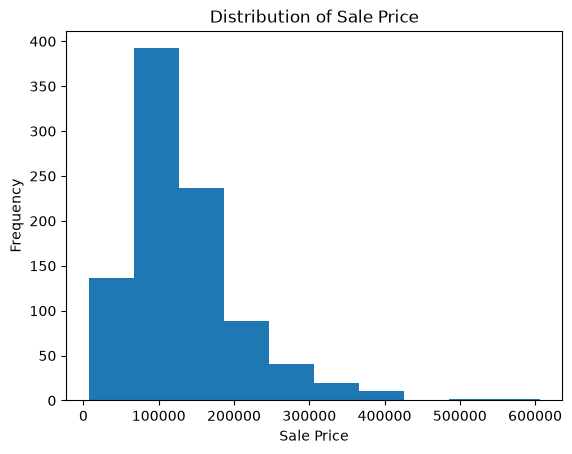

In [41]:
df["SalePrice"].plot.hist()

plt.xlabel("Sale Price")
plt.title("Distribution of Sale Price")
plt.show()

<Axes: ylabel='Frequency'>

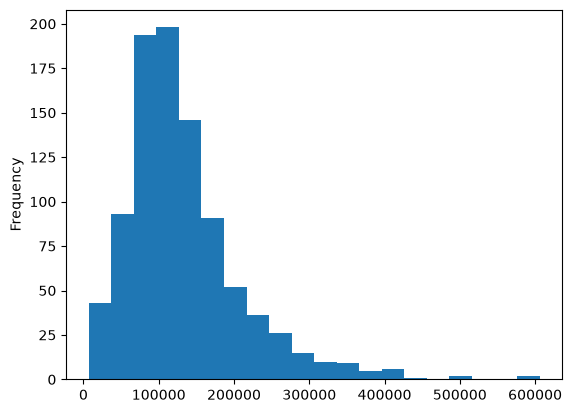

In [46]:
# กำหนดจำนวนช่วงด้วย bins
df["SalePrice"].plot.hist(bins=20)

### 8.2. Box Plot — ใช้ดูการกระจายและ Outliers

### เหมาะสำหรับดู median, spread และ potential outliers

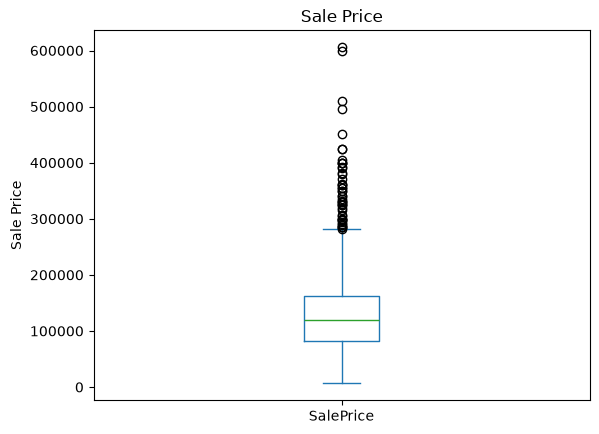

In [47]:
df["SalePrice"].plot.box()

plt.ylabel("Sale Price")
plt.title("Sale Price")
plt.show()

### 8.3. Scatter Plot — ดูความสัมพันธ์ระหว่างตัวแปร

### เช่น พื้นที่บ้านกับราคาขาย

> ### <u>EDA question</u> : บ้านที่มีพื้นที่มากขึ้นมีแนวโน้มราคาสูงขึ้นหรือไม่?

> #### มีความสัมพันธ์เชิงบวก (positive relationship) ระหว่าง SquareFeet และ SalePrice ค่ะ กล่าวคือ
> โดยทั่วไป เมื่อพื้นที่บ้านเพิ่มขึ้น ราคาขายก็มีแนวโน้มเพิ่มขึ้น
> แต่ความสัมพันธ์ไม่ได้สมบูรณ์แบบ เพราะบ้านที่มีพื้นที่ใกล้เคียงกันสามารถมีราคาขายแตกต่างกันมาก แสดงว่า SalePrice น่าจะได้รับอิทธิพลจากปัจจัยอื่นด้วย ไม่ใช่เพียง SquareFeet

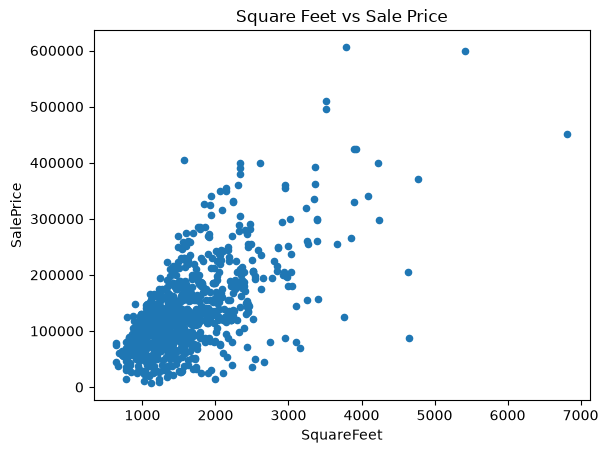

In [48]:
df.plot.scatter(
    x="SquareFeet",
    y="SalePrice"
)

plt.title("Square Feet vs Sale Price")
plt.show()

แนวโน้มระหว่างราคาขายบ้านและพื้นที่บ้านมีแนวโน้มไปในทิศทางเดียวกันคือยิ่งพื้นที่มีขนาดมากขึ้น ราคาขายก็จะสูงขึ้นตามโดยดูจากการกระจุกตัวตามแนวเส้น

(ความสัมพันธ์เชิงบวก)

### 8.4. Bar Chart — เปรียบเทียบกลุ่ม

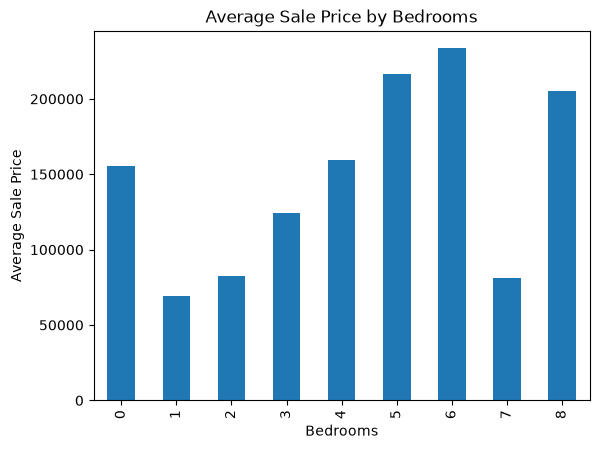

In [49]:
avg_price = df.groupby("Bedrooms")["SalePrice"].mean()

avg_price.plot.bar()

plt.ylabel("Average Sale Price")
plt.title("Average Sale Price by Bedrooms")
plt.show()

ยิ่งจำนวนของห้องนอนมากขึ้น ราคาขายก้ยิ่งสูงขึ้น

### 8.5. Line Plot — ดู Trend

#### เนื่องจาก YearSold มีลำดับตามเวลา Line Plot จึงเหมาะกว่ากราฟแท่งหากต้องการเน้น trend

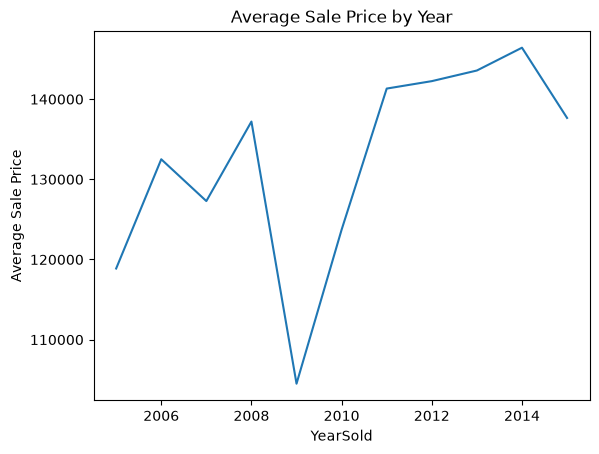

In [50]:
avg_price = df.groupby("YearSold")["SalePrice"].mean()

avg_price.plot()

plt.ylabel("Average Sale Price")
plt.title("Average Sale Price by Year")
plt.show()

ราคาขายบ้านในปี 2009 ตกลงอย่างมาก ส่วนแนวโน้มของราคาขายกับปีมีแนวโน้มที่จะสูงขึ้น กล่าวคือยิ่งปีสูง ราคาเฉลี่ยก็ยิ่งสูง

8.6. Bar Chart จาก crosstab()

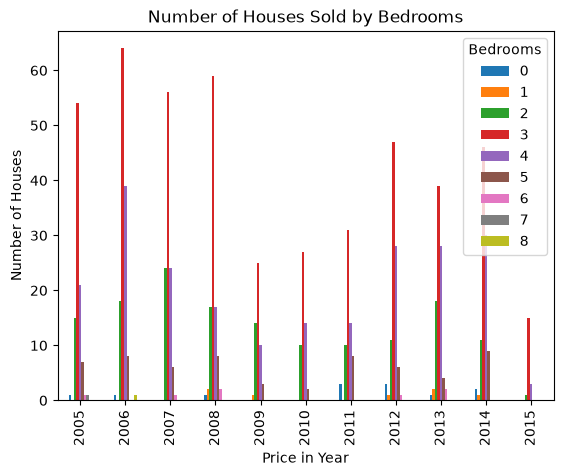

In [52]:
table = pd.crosstab(
    df["YearSold"],
    df["Bedrooms"]
)

table.plot.bar()

plt.ylabel("Number of Houses")
plt.xlabel("Price in Year")
plt.title("Number of Houses Sold by Bedrooms")
plt.show()